In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import glob
import os
import numpy as np
import itertools
import ast
import datetime
import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import warnings
from scipy.interpolate import griddata
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib as mpl
import iris

import iris.quickplot as qplt
import iris.plot as iplt
degree_sign= u'\N{DEGREE SIGN}'
import cmocean
import xarray as xr

def format_x_and_y_ticks(ax: plt.axes, xlocs: list, ylocs: list):
    """Format geoaxes ticks.

    Args:
        ax (plt.axes): axes
        xlocs (list): x locations
        ylocs (list): y locations

    Returns:
        ax: axes
    """

    # Make nicely formatted x- and y-ticks
    xlabels = []
    for j in range(len(xlocs)):
        if xlocs[j] > 0 :
            xlabels.append(f"{abs(xlocs[j]):.1f}{degree_sign}E")
        elif xlocs[j] == 0:
            xlabels.append(f"{abs(xlocs[j]):.0f}{degree_sign}")
        else:
            xlabels.append(f"{abs(xlocs[j]):.1f}{degree_sign}W")
            
    ax.set_xticks(xlocs)
    ax.set_xticklabels(xlabels)

    ylabels = []
    for j in range(len(ylocs)):
        if ylocs[j] < 0 :
            ylabels.append(f"{abs(ylocs[j]):.1f}{degree_sign}S")
        elif ylocs[j] == 0:
            ylabels.append(f"{abs(ylocs[j]):.0f}{degree_sign}")
        else:
            ylabels.append(f"{ylocs[j]:.1f}{degree_sign}N")
    ax.set_yticks(ylocs)
    ax.set_yticklabels(ylabels)
    ax.grid(linewidth=0.3)
    ax.set_xlabel("")
    ax.set_ylabel("")

    return ax

def circ_mean(h):
    return (np.arctan2(np.sin(2*np.pi*h/24).mean(),np.cos(2*np.pi*h/24).mean()) * 24/(2*np.pi)) % 24

In [2]:
models = ["n1280_CoMA9", "n1280_GAL9_v2", "n2560_CoMA9_hier_v2", "n2560_RAL3p3_tuned"]

In [3]:
def load_mcs(model_id):
    files = glob.glob(f"/gws/ssde/j25a/ncas_climate/vol1/users/ekarl20/data/hackathon_monsoon_data/{model_id}/*.csv")
    
    dfs = []
    
    for file in files:
        dfs.append(pd.read_csv(file))
    
    df = pd.concat(dfs)
    df["timestamp"] = pd.to_datetime(df.timestamp)
    df["model_id"] = model_id

    return df

dfs = []

for model_id in models:
    dfs.append(load_mcs(model_id))

df = pd.concat(dfs)

In [4]:
def subset_domain(lat1: float, lat2: float, lon1: float, lon2: float, df: pd.DataFrame, storm_label="Storm"):
    """Subset dataframe of storm track with storms that at any
    point cross the box with given latitude and longitude bounds

    Args:
        lat1 (float): minimum latitude
        lat2 (float): maximum latitude
        lon1 (float): minimum longitude
        lon2 (float): maximum longitude
        df (pd.DataFrame): dataframe to subset
        storm_label (str, optional): storm identifier column. Defaults to "Storm".

    Returns:
        _type_: _description_
    """
   
    df["LonInBounds"] = (df.lon <= lon2) & (df.lon >= lon1)
    df["LatInBounds"]= (df.lat <= lat2) & (df.lat >= lat1)
    df["in_domain"] = df["LonInBounds"] & df["LatInBounds"]
    
    # Find any points within each storm that cross domain
    storms_in_domain = df.groupby(storm_label).size()[df.groupby(storm_label).in_domain.any()]
    storms_in_domain = storms_in_domain.index
    
    df = df[df[storm_label].isin(storms_in_domain)]

    return df

In [5]:
def find_regions(region):

    regions = { "West Africa": {"lat_min": 0, "lat_max": 25, "lon_min": -25, "lon_max": 20}, 
        "South Asia": {"lat_min": 0, "lat_max": 35, "lon_min": 50, "lon_max": 110},
        "East Asia": {"lat_min": 15, "lat_max": 50, "lon_min": 95, "lon_max": 150},
        "North America": {"lat_min": 0, "lat_max": 35, "lon_min": -120, "lon_max": -60},
        "Southern Africa": {"lat_min": -35, "lat_max": -5, "lon_min": 5, "lon_max": 50},
        "Maritime Continent": {"lat_min": -30, "lat_max": 20, "lon_min": 100, "lon_max": 160},
        "South America": {"lat_min": -35, "lat_max": 10, "lon_min": -90, "lon_max": -30}}
    
    return regions[region]
        
regions_list = ["West Africa", "South Asia", "East Asia", "North America", "Southern Africa", "Maritime Continent", "South America"]

In [6]:
df["pr_meanxarea"] = df.pr_mean*df.area

In [8]:
mcs_count = np.zeros((len(models), len(regions_list), 12))
rainfall = np.zeros((len(models), len(regions_list), 12))

for mdx, model_id in enumerate(models):
    df_ = df[df.model_id == model_id]
    df_storm = df_.groupby("storm_id").first().reset_index()
    for rdx, region in enumerate(regions_list):
        region_bounds = find_regions(region)
        lat1, lat2, lon1, lon2 = region_bounds["lat_min"], region_bounds["lat_max"], region_bounds["lon_min"],  region_bounds["lon_max"]
        # print(lat1, lat2, lon1, lon2)
        df2 = subset_domain(lat1, lat2, lon1, lon2, df_storm, storm_label="storm_id")
        #print(df_storm)
        # print(region, len(df2))
        mcs_count[mdx, rdx] = df2.groupby(df2.timestamp.dt.month).size().reindex(range(1,13), fill_value=0)
        rainfall[mdx, rdx] = (df2.groupby(df2.timestamp.dt.month).pr_meanxarea.sum()).reindex(range(1,13), fill_value=0)

In [9]:
colour_dict = {"n2560_CoMA9_hier_v2": "royalblue",
               "n2560_RAL3p3_tuned": "forestgreen",
              "n1280_CoMA9": "magenta",
               "n1280_GAL9_v2": "gold"
              }

# MCSs that pass each monsoon domain

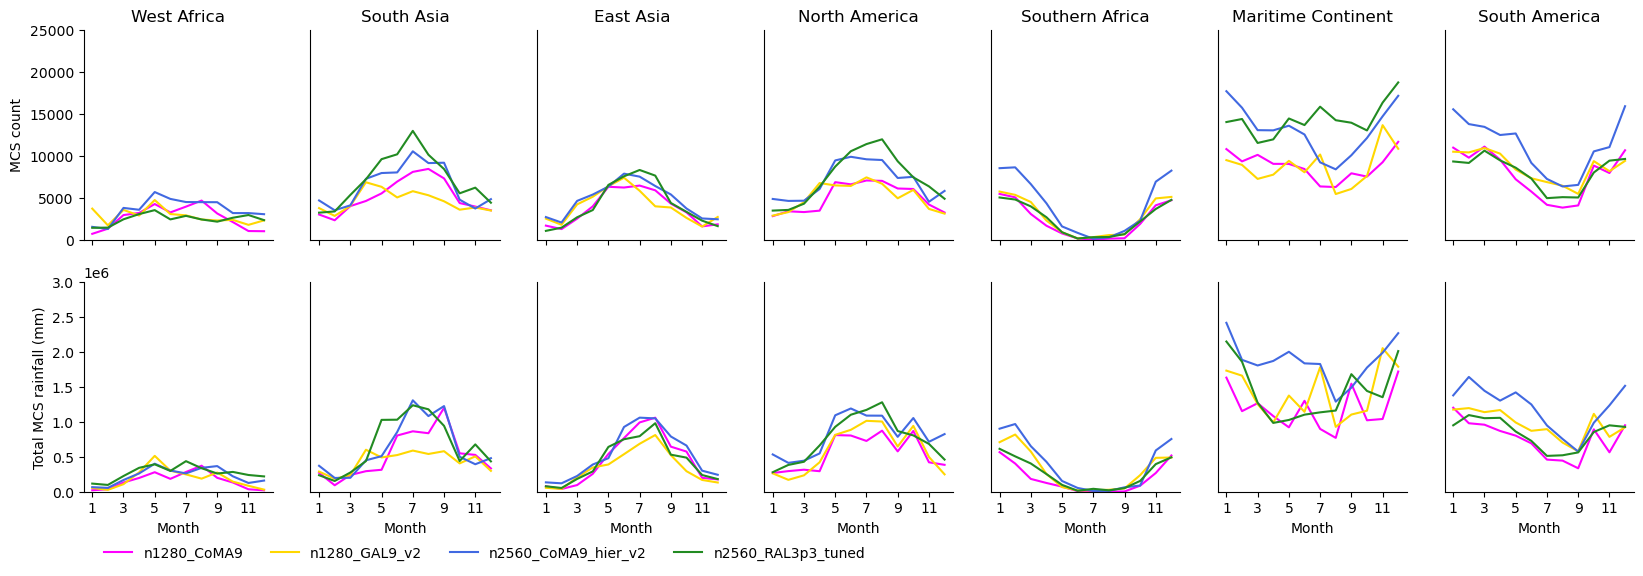

In [93]:
fig, axes = plt.subplots(2,len(regions_list), figsize=(20,6), sharex=True)

for mdx, model_id in enumerate(models):
    for rdx, region in enumerate(regions_list):
        axes[0,rdx].plot(range(1,13), mcs_count[mdx,rdx], color=colour_dict[model_id], label=model_id)
        axes[0,rdx].set_title(regions_list[rdx])
        axes[1,rdx].set_xlabel("Month")
        axes[0,rdx].set_xticks(range(1,13, 2))
        axes[0,rdx].set_ylim(0,25000)

        axes[1,rdx].plot(range(1,13), rainfall[mdx,rdx], color=colour_dict[model_id], label=model_id)
        axes[1,rdx].set_ylim(0,3e6)

        if rdx > 0:
            axes[0,rdx].axes.get_yaxis().set_ticks([])
            axes[1,rdx].axes.get_yaxis().set_ticks([])

for ax in axes.ravel():
    ax.spines[['right', 'top']].set_visible(False)
        
axes[0,0].set_ylabel("MCS count")
axes[1,0].set_ylabel("Total MCS rainfall (mm)")

axes[1,0].legend(frameon=False, ncols=4, bbox_to_anchor=(4.2,-0.2))
        
plt.show()

In [35]:
seasons = {"OND": [10,11,12],
          "JJAS": [6,7,8,9],
          "JF": [1,2],
          "MAM": [3,4,5]}

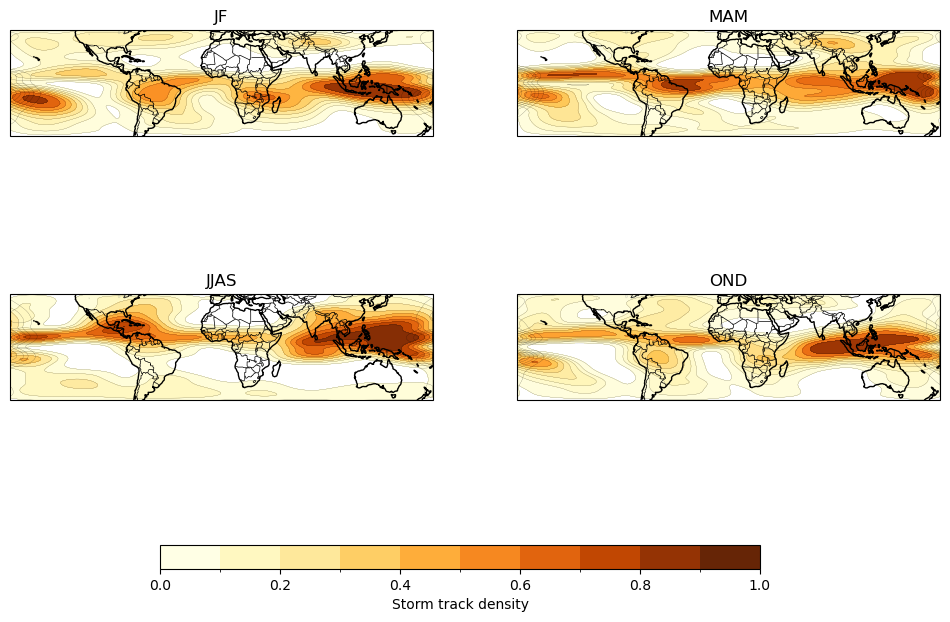

In [30]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

extent = [30.0, 35.5, -3.5, 1.5]
xlocs = [31.5, 33, 34.5]
ylocs = [-3,-1.5,0,1.5]

figsize=(6*2,6*2)

fig, axes = plt.subplots(2,2, figsize=figsize,subplot_kw=dict(projection=ccrs.PlateCarree(central_longitude=0)), facecolor="white")


cmap=plt.get_cmap("twilight")
bounds=np.arange(0,25,1)

norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

# df_obs2 = df_obs.groupby("Storm").first()
# df2 = df.groupby("storm_id").first()

season_list = ["JF", "MAM", "JJAS", "OND"]

for i, ax in enumerate(axes.ravel()):
    season = season_list[i]
    ax.coastlines(resolution="110m")
    ax.set_extent([-180,180,-45,45])
    
    ax.add_feature(cfeature.BORDERS, edgecolor="black", linewidths=0.5)
    ax.add_feature(cfeature.LAKES, edgecolor="black", linewidths=0.5, alpha=0.1)
    
    df2 = df.groupby("storm_id").first()
    df2 = df2[df2.timestamp.dt.month.isin(seasons[season])]
    
    kde1 = sns.kdeplot(x=df2.lon,  y=df2.lat, ax=ax, fill=True, cmap="YlOrBr", alpha=1)
    
    kde = sns.kdeplot(x=df2.lon,  y=df2.lat, ax=ax, fill=False, color="black",
                        linewidths=0.1)
    ax.set_title(season)
    
    
    # sc = ax.scatter(df2.lon, df2.lat, c=df2.eat_hours, cmap=cmap, norm=norm, s=10, transform=ccrs.PlateCarree())
    
    # ax.set_title(extents[storm_type]['label'], color=extents[storm_type]['color'])
    
    ax.set_xlabel("")
    ax.set_ylabel("")


cmap = mpl.cm.YlOrBr
bounds = np.arange(0.,1.01,0.1)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

cbar_ax = fig.add_axes([0.25, 0.20, 0.5, 0.02])   # [left, bottom, width, height]

cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax, orientation='horizontal')
cbar.set_label("Storm track density")

plt.subplots_adjust(hspace=-0.6)

plt.show()

Day of year for onset period (start and end)

In [7]:
models = ["n1280_CoMA9", "n1280_GAL9_v2", "n2560_CoMA9_hier_v2", "n2560_RAL3p3_tuned"]

models_dict = {"um_glm_n1280_CoMA9_hk26": "n1280_CoMA9",
              "um_glm_n1280_GAL9_v2_hk26": "n1280_GAL9_v2",
              "um_glm_n2560_CoMA9_hk26":  "n2560_CoMA9_hier_v2",
             "um_glm_n2560_RAL3p3_tuned_hk26":  "n2560_RAL3p3_tuned"}

model_list = ["um_glm_n1280_CoMA9_hk26", "um_glm_n1280_GAL9_v2_hk26", "um_glm_n2560_CoMA9_hk26",
            "um_glm_n2560_RAL3p3_tuned_hk26"]

In [8]:
files = glob.glob("/gws/nopw/j04/kscale/USERS/fmorris/onset_dates/*")
files

['/gws/nopw/j04/kscale/USERS/fmorris/onset_dates/guide_to_files.md',
 '/gws/nopw/j04/kscale/USERS/fmorris/onset_dates/um_glm_n1280_CoMA9_hk26_zoom_3_first_days.nc',
 '/gws/nopw/j04/kscale/USERS/fmorris/onset_dates/um_glm_n1280_CoMA9_hk26_zoom_3_last_days.nc',
 '/gws/nopw/j04/kscale/USERS/fmorris/onset_dates/um_glm_n1280_CoMA9_hk26_zoom_4_first_days.nc',
 '/gws/nopw/j04/kscale/USERS/fmorris/onset_dates/um_glm_n1280_CoMA9_hk26_zoom_4_last_days.nc',
 '/gws/nopw/j04/kscale/USERS/fmorris/onset_dates/um_glm_n1280_CoMA9_hk26_zoom_5_first_days.nc',
 '/gws/nopw/j04/kscale/USERS/fmorris/onset_dates/um_glm_n1280_CoMA9_hk26_zoom_5_last_days.nc',
 '/gws/nopw/j04/kscale/USERS/fmorris/onset_dates/um_glm_n1280_CoMA9_hk26_zoom_6_first_days.nc',
 '/gws/nopw/j04/kscale/USERS/fmorris/onset_dates/um_glm_n1280_CoMA9_hk26_zoom_6_last_days.nc',
 '/gws/nopw/j04/kscale/USERS/fmorris/onset_dates/um_glm_n1280_GAL9_v2_hk26_zoom_3_first_days.nc',
 '/gws/nopw/j04/kscale/USERS/fmorris/onset_dates/um_glm_n1280_GAL9_v2

In [9]:
from pathlib import Path

filepath = "/gws/nopw/j04/kscale/USERS/fmorris/onset_dates/"

def load_onset(label, zoom):

    data = []
    
    for model_id in model_list:
        data.append(xr.open_dataset(Path(filepath) / f"{model_id}_zoom_{zoom}_{label}_days.nc"))

    data = xr.concat(data, dim="model_id")

    data = data.assign_coords(model_id=model_list)
    data = data.assign_coords({"zoom": zoom})

    return data

In [10]:
zoom = 4
onset_start = load_onset("first", zoom)
onset_start["pr"] = (onset_start["pr"]-21) % 365
onset_end = load_onset("last", zoom)
onset_end["pr"] = (onset_end["pr"]-21) % 365

In [ ]:
onset_end - onset_start

In [11]:
def get_region_mask(lat1, lat2, lon1, lon2, ds3h_plot):

    if lon1 < 0:
        region_mask = (ds3h_plot.lat >= lat1) & (ds3h_plot.lat <= lat2) & ((ds3h_plot.lon >= lon1+360) &  (ds3h_plot.lon <= lon2+360) |(ds3h_plot.lon >= lon1) &  (ds3h_plot.lon <= lon2)  )
    else:
        region_mask = (ds3h_plot.lat >= lat1) & (ds3h_plot.lat <= lat2) & (ds3h_plot.lon >= lon1) &  (ds3h_plot.lon <= lon2)

    return region_mask

import cartopy.crs as ccrs
import intake
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import easygems.healpix as egh
degree_sign= u'\N{DEGREE SIGN}'

# from utils import hp_mods, plot_all_fields

In [12]:
df["dayofyear"] = df.timestamp.dt.dayofyear

In [16]:
model_id = "um_glm_n1280_GAL9_v2_hk26"

region_bounds = find_regions(region)
lat1, lat2, lon1, lon2 = region_bounds["lat_min"], region_bounds["lat_max"], region_bounds["lon_min"],  region_bounds["lon_max"]
# print(lat1, lat2, lon1, lon2)
df2 = subset_domain(lat1, lat2, lon1, lon2, df[df.model_id == models_dict[model_id]], storm_label="storm_id")

In [17]:
df3 = df2.groupby("storm_id").first()

In [18]:
df3.iloc[0].dayofyear

np.int32(32)

In [19]:
lat = df2.iloc[0].lat
lon = df2.iloc[0].lon

In [20]:
onset_start_ = onset_start.sel(model_id=model_id, period=0)["pr"].sel(latitude=lat, longitude=lon, method="nearest")
onset_end_ = onset_end.sel(model_id=model_id, period=0)["pr"].sel(latitude=lat, longitude=lon, method="nearest")

onset_start_.values <= df3.iloc[0].dayofyear <= onset_end_.values

np.False_

In [13]:
def find_if_in_onset(x, onset_start, onset_end):

    lat = x.lat
    lon = x.lon
    day = x.dayofyear

    start = onset_start.sel(latitude=lat, longitude=lon, method="nearest").values
    end = onset_end.sel(latitude=lat, longitude=lon, method="nearest").values

    if start <= end:
        # e.g. 5 <= 15 <= 30
        return start <= day <= end
    else:
        # e.g. 240 <= 15 <= 20 
        return day >= start or day <= end


In [88]:
start = 240
end = 20
x = 15

# start = 5
# end = 30
# x = 15

if start <= end:
    print(start <= x <= end)
else:
    print(x >= start or x <= end)

True


In [ ]:
# df3["in_onset"] = df3.apply(lambda x: find_if_in_onset(x, onset_start.sel(model_id=model_id, period=0)["pr"], onset_end.sel(model_id=model_id, period=0)["pr"]), axis=1)

In [55]:
find_if_in_onset(df2[df2.storm_id==20].iloc[0], onset_start.sel(model_id=model_id, period=0)["pr"], onset_end.sel(model_id=model_id, period=0)["pr"])

362.0 427.0


np.False_

In [52]:
df2[df2["storm_id"] == 20].iloc[0]

storm_id                         20
life                             94
area                          14249
Initial_UTC     2020-02-01 23:04:00
Final_UTC       2020-02-05 20:04:00
lon                      -47.042111
lat                      -23.710404
u                          9.473515
v                          2.346343
pr_mean                    0.711791
pr_max                    13.208964
pr_perc90                  2.408804
min_BT                   194.962319
mean_BT                  228.946302
timestamp       2020-02-01 23:04:00
model_id              n1280_GAL9_v2
pr_meanxarea           10142.311651
dayofyear                        32
LonInBounds                    True
LatInBounds                    True
in_domain                      True
Name: 66, dtype: object

In [31]:
region, model_id

('South America', 'um_glm_n1280_GAL9_v2_hk26')

In [41]:
df3_monsoon = df3[df3.in_onset == True]
monsoon_storms = df3_monsoon.index 
df2_monsoon = df2[df2.storm_id.isin(monsoon_storms)]
df2_monsoon.pr_meanxarea.sum()

np.float64(34562136.87450536)

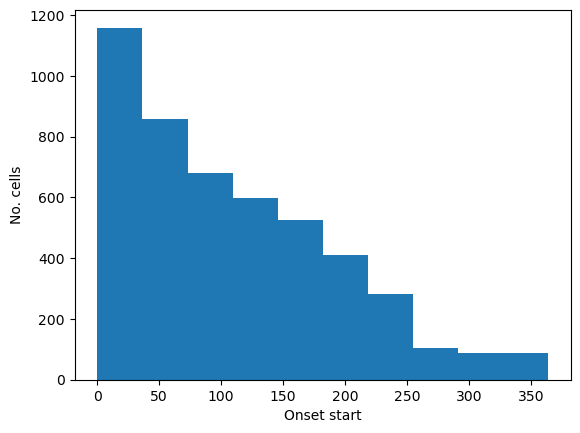

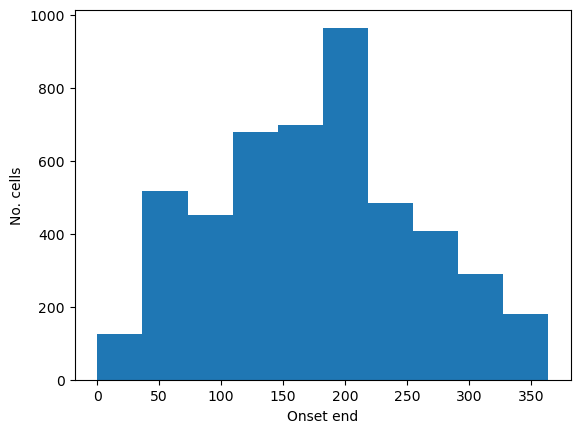

In [78]:
plt.hist(onset_start["pr"].sel(period=0).values.flatten())
plt.xlabel("Onset start")
plt.ylabel("No. cells")
plt.show()

plt.hist(onset_end["pr"].sel(period=0).values.flatten())
plt.xlabel("Onset end")
plt.ylabel("No. cells")
plt.show()

In [ ]:
# Subset all the MCS that initiate in the area
region_bounds = find_regions(region)
lat1, lat2, lon1, lon2 = region_bounds["lat_min"], region_bounds["lat_max"], region_bounds["lon_min"],  region_bounds["lon_max"]

df2 =  df[df.model_id == models_dict[model_id]]
df2_ = df2.groupby("storm_id").first()
df2_ = df2_[(df2_.lat >= lat1) & (df2_.lat <= lat2) & (df2_.lon >= lon1) & (df2_.lon <= lon2)]
print(df2_.lat.min(), df2_.lat.max(), df2_.lon.min(), df2_.lon.max())

In [14]:
data = []

for model_id in model_list:
    for region in regions_list:
        print(model_id, region)

        # Subset all the MCS that initiate in the area
        region_bounds = find_regions(region)
        lat1, lat2, lon1, lon2 = region_bounds["lat_min"], region_bounds["lat_max"], region_bounds["lon_min"],  region_bounds["lon_max"]
        
        df2 =  df[df.model_id == models_dict[model_id]]
        df2_ = df2.groupby("storm_id").first()
        df2_ = df2_[(df2_.lat >= lat1) & (df2_.lat <= lat2) & (df2_.lon >= lon1) & (df2_.lon <= lon2)]
        print(df2_.lat.min(), df2_.lat.max(), df2_.lon.min(), df2_.lon.max())

        # Find monsoon onset
        df2_["in_onset"] = df2_.apply(lambda x: find_if_in_onset(x, onset_start.sel(model_id=model_id, period=0)["pr"], onset_end.sel(model_id=model_id, period=0)["pr"]), axis=1)
        df2_["region"] = region

        print(len(df2_), len(df2_)/12, df2_.in_onset.sum(), df2_.in_onset.sum()/len(df2_))

        data.append(df2_)

data_concat = pd.concat(data).reset_index()
data_concat.to_csv(f"/gws/ssde/j25a/ncas_climate/vol1/users/ekarl20/data/hackathon_monsoon_data/monsoon_onset_data_all_models_and_monsoon_regions_zoom_{zoom}.csv", index=False)

um_glm_n1280_CoMA9_hk26 West Africa
7.105427357601002e-15 24.998648648648658 -24.99999999999996 19.999367088607634
31625 2635.4166666666665 10050 0.31778656126482213
um_glm_n1280_CoMA9_hk26 South Asia
8.720297211601231e-15 34.99897959183674 50.00000000000004 109.9989795918368
62107 5175.583333333333 16799 0.27048480847569517
um_glm_n1280_CoMA9_hk26 East Asia
15.000000000000004 49.99545454545455 95.00000000000004 149.99651162790704
45357 3779.75 13050 0.2877174416297374
um_glm_n1280_CoMA9_hk26 North America
8.881784197001252e-15 34.998648648648654 -119.99999999999996 -60.00135135135133
60136 5011.333333333333 12236 0.20347212983903154
um_glm_n1280_CoMA9_hk26 Southern Africa
-34.99896174863388 -5.0006329113923975 5.019444444444488 49.99838709677423
27240 2270.0 6501 0.23865638766519823
um_glm_n1280_CoMA9_hk26 Maritime Continent
-29.99925373134328 19.999218750000008 100.00000000000004 159.99893617021283
105729 8810.75 23271 0.22010044547853475
um_glm_n1280_CoMA9_hk26 South America
-34.999

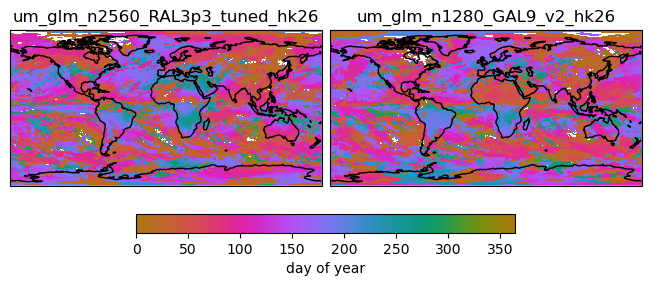

In [101]:
import cmocean as cmo

projection = ccrs.PlateCarree()
fig, axes = plt.subplots(
    1,
    2,
    # height_ratios=[1] * len(zooms) + [0.1],
    # figsize=(6, 10),
    subplot_kw={"projection": projection},
    layout="constrained",
)
sim="um_glm_n2560_RAL3p3_tuned_hk26"
axes[0].coastlines()
axes[0].set_global()

filepath = "/gws/nopw/j04/kscale/USERS/fmorris/onset_dates/"

da = onset_start_ = (xr.open_dataarray(Path(filepath) / f"{sim}_zoom_6_first_days.nc")).sel(period=0)
m=da.plot(cmap=cmo.cm.phase,vmin=0,vmax=365, ax=axes[0],add_colorbar=False)
axes[0].set_title(sim)

sim="um_glm_n1280_GAL9_v2_hk26"
axes[1].coastlines()
axes[1].set_global()
da = (xr.open_dataarray(Path(filepath) / f"{sim}_zoom_6_first_days.nc")).sel(period=0)
m=da.plot(cmap=cmo.cm.phase,vmin=0,vmax=365, ax=axes[1],add_colorbar=False)
axes[1].set_title(sim)

# im=egh.healpix_show(da,cmap=cmo.cm.phase)
# plt.colorbar(im)

fig.colorbar(
        m,
        ax=axes.ravel().tolist(),
        orientation="horizontal",
        fraction=0.05,
        pad=0.07,
        shrink=0.7,
        label="day of year",
)

# East Africa

In [65]:
dfs = []
fnames = glob.glob("../../storms_hill_etal*.csv")

for fname in fnames:
    dfs.append(pd.read_csv(fname))

df_obs_gah = pd.concat(dfs)
df_obs_gah["Initial UTC"] = pd.to_datetime(df_obs_gah["Initial UTC"])
df_obs_gah["Final UTC"] = pd.to_datetime(df_obs_gah["Final UTC"])

df_obs_gah["duration"] = df_obs_gah["Final UTC"] - df_obs_gah["Initial UTC"]
df_obs_gah["duration_hr"] = df_obs_gah["duration"].dt.total_seconds()/3600.0
df_obs_gah = df_obs_gah[df_obs_gah.duration_hr >= 1]

In [38]:
lat1, lat2, lon1, lon2 = -10, 12, 30, 52

df_gah = subset_domain(lat1, lat2, lon1, lon2, df, storm_label="storm_id")

In [74]:
resolution = {"n1280_CoMA9": 10, 
              "n1280_GAL9_v2": 10, 
              "n2560_CoMA9_hier_v2": 5,
              "n2560_RAL3p3_tuned": 5}

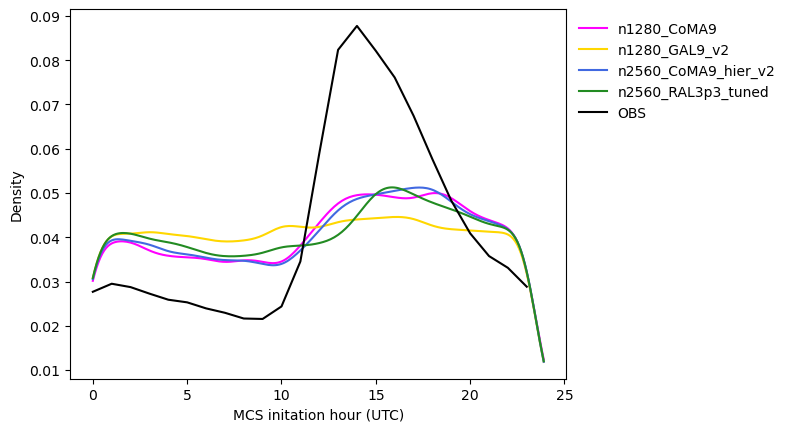

In [103]:
from scipy.stats import gaussian_kde

for model in models:

    kde = gaussian_kde((df_gah[df_gah.model_id == model].groupby(["storm_id"]).first().timestamp+datetime.timedelta(hours=3)).dt.hour)
    bins = np.arange(0,24,0.1)
    plt.plot(bins,kde(bins),color=colour_dict[model], label=model)

bins = np.arange(0,24,1)
df2_ = df_obs_gah[df_obs_gah.Area*4.4*4.4 >= 1000].groupby("Storm").first()
kde = gaussian_kde((df2_["Initial UTC"]+datetime.timedelta(hours=3)).dt.hour)
plt.plot(bins, kde(bins), label="OBS", color="black")

plt.legend(frameon=False, ncols=1, bbox_to_anchor=(1,1))

plt.xlabel("MCS initation hour (UTC)")
plt.ylabel("Density")

plt.show()